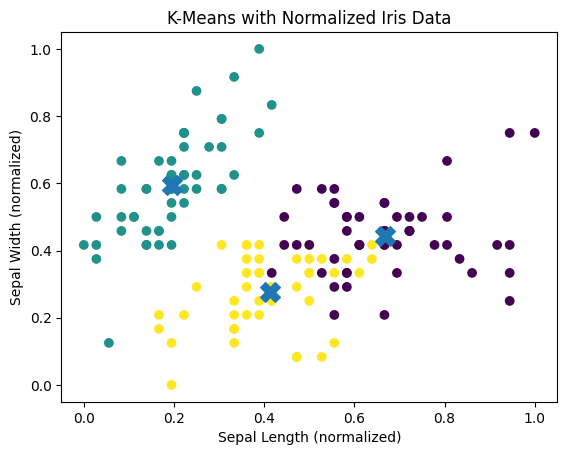

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# Load the Iris data set
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Normalize the data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df)

# Train k-means
kmeans = KMeans(n_clusters=3, random_state=42, max_iter=200)
kmeans.fit(X_scaled)

# Get labels and cluster centers
labels = kmeans.labels_
centers = kmeans.cluster_centers_

# Plot normalized data using the first two features
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.scatter(centers[:, 0], centers[:, 1], marker='X', s=200)

plt.xlabel("Sepal Length (normalized)")
plt.ylabel("Sepal Width (normalized)")
plt.title("K-Means with Normalized Iris Data")
plt.show()

In [45]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import AgglomerativeClustering

# Load the Iris dataset
iris = load_iris()
X = iris.data

# Min-max normalization
scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X)

# Hierarchical agglomerative clustering
model = AgglomerativeClustering(
    n_clusters=3,
    metric="euclidean",
    linkage="complete",
)

model.fit(X_norm)
model.labels_


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 1, 1, 1, 2, 1, 2, 1,
       1, 2, 1, 2, 2, 1, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 2, 2, 1, 1, 1, 1,
       1, 2, 2, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2])

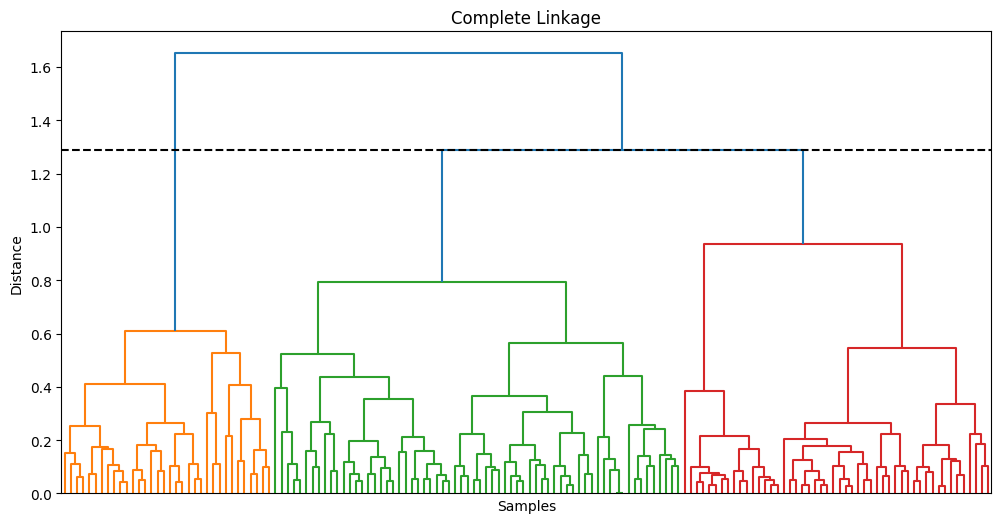

Cluster labels:
[3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 1 1 1 1 2 1 2 1 1
 2 1 2 2 1 1 1 1 2 1 2 1 2 1 1 2 2 1 1 1 1 1 2 2 1 1 1 2 1 1 1 2 1 1 1 2 1
 1 2]

Cluster vs true species:
species  setosa  versicolor  virginica
cluster                               
1             0           1         33
2             0          49         17
3            50           0          0


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Load the Iris dataset
iris = load_iris()
X = iris.data

# Min-max normalization
scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X)

# Hierarchical clustering with average linkage
Z = linkage(X_norm, method="complete", metric="euclidean")

# Choose 3 clusters
k = 3
threshold = Z[-(k - 1), 2]

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(
    Z,
    no_labels=True,
    color_threshold=threshold
)

plt.axhline(y=threshold, color="black", linestyle="--")
plt.title("Complete Linkage")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

# Create cluster labels
clusters = fcluster(Z, t=3, criterion="maxclust")
print("Cluster labels:")
print(clusters)

# Optional: compare clusters with true iris classes
species = [iris.target_names[i] for i in iris.target]
df = pd.DataFrame({
    "cluster": clusters,
    "species": species
})

print("\nCluster vs true species:")
print(pd.crosstab(df["cluster"], df["species"]))

In [47]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import pandas as pd

# Load the Iris dataset
iris = load_iris()
X = iris.data
species = [iris.target_names[i] for i in iris.target]

# Standardize the data
X_scaled = StandardScaler().fit_transform(X)

# Apply DBSCAN
model = DBSCAN(eps=0.85, min_samples=4)
labels = model.fit_predict(X_scaled)

# Put results into a table
df = pd.DataFrame(X, columns=iris.feature_names)
df["species"] = species
df["cluster"] = labels

print(df.head())
print("\nCluster counts:")
print(df["cluster"].value_counts().sort_index())

print("\nCluster vs true species:")
print(pd.crosstab(df["cluster"], df["species"]))

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  cluster  
0  setosa        0  
1  setosa        0  
2  setosa        0  
3  setosa        0  
4  setosa        0  

Cluster counts:
cluster
-1     4
 0    49
 1    97
Name: count, dtype: int64

Cluster vs true species:
species  setosa  versicolor  virginica
cluster                               
-1            1           0          3
 0           49           0          0
 1            0          50         47


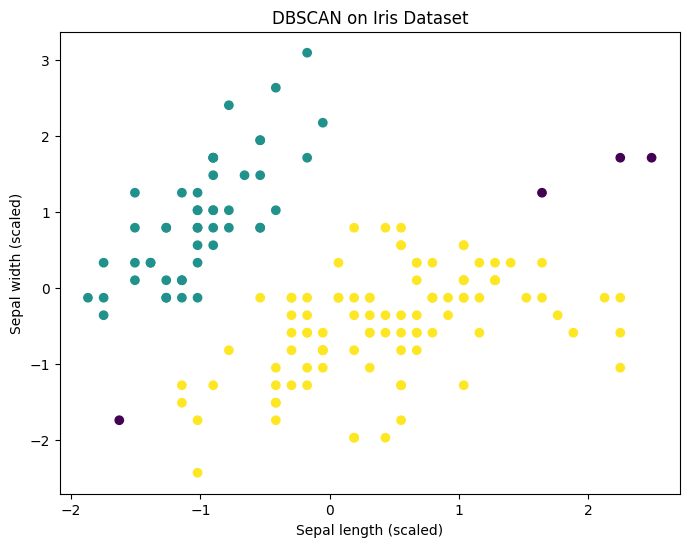

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.title("DBSCAN on Iris Dataset")
plt.xlabel("Sepal length (scaled)")
plt.ylabel("Sepal width (scaled)")
plt.show()

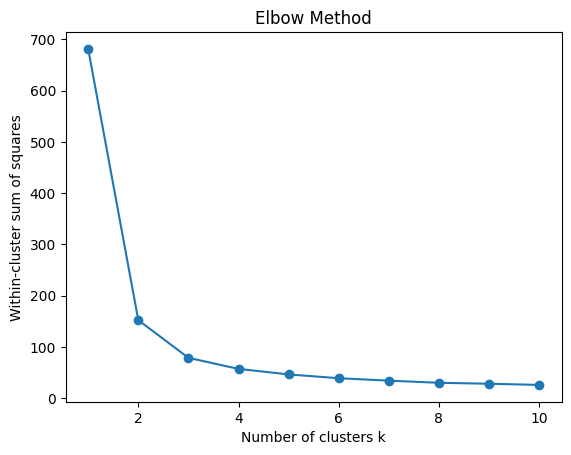

In [49]:
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

X = load_iris().data

errors = []
k_values = range(1, 11)

for k in k_values:
    model = KMeans(n_clusters=k, n_init=10, random_state=42)
    model.fit(X)
    errors.append(model.inertia_)

plt.plot(k_values, errors, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Within-cluster sum of squares")
plt.title("Elbow Method")
plt.show()